# NFA phase sweep

Refactor of `multi-index.ipynb`. Every code cell below is either **copied verbatim** from that
notebook or is new config/driver glue; nothing is rewritten.

**Structure rules** (why the notebook looks like this):
1. All parameters come from `configs/*.yaml` — nothing is hard-coded in a cell.
2. Cells define functions; they do not mutate globals. The old notebook rebound `state` at
   cells 7, 35, 36 and inside every sweep loop, so re-running a cell silently changed results.
3. Plot functions take data and return a figure, so a sweep can save them per run.
4. No scratch probes. The ~45 one-line inspection cells are gone.

Run one config, or expand a sweep file and run the grid. Both paths call the same `run_one`.

## 0. Imports and device configuration

In [1]:
# GPU config MUST precede `import jax` -- these are read at backend init.
import os
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"   # don't reserve ~75% of VRAM up front

In [2]:
import os
import sys
sys.path.insert(1, os.path.abspath(os.path.join('..', 'src')))

# Import numerical computing libraries
import jax
import jax.numpy as jnp
import jax.random as jr
import jax.scipy.linalg as jla

from jax import grad, jit, vmap
from jax.flatten_util import ravel_pytree

from optax import l2_loss

# Import plotting libraries
import matplotlib.pyplot as plt
from IPython.display import HTML
from ipywidgets import interact, FloatSlider
from matplotlib.animation import FuncAnimation

from networks import MLP
# from ntk import entk, nvp, compute_ntk_eigs
from ntk import nvp, compute_ntk_eigs
# from hess import hvp, unravel_hvp, compute_hessian_eigs
from hess import _hvp_flat, compute_hessian_eigs
from opt import train, batch_loss, gd_update, TrainState
from nn_utils import (
    get_activations, 
    neuron_sparsity, 
    neuron_covariance, 
    compute_neuron_cov_eigs, 
    compute_neuron_cov_stats
    
)
from agop import (
    agop, 
    compute_agop, 
    compute_agop_eigs, 
    compute_nfa_eigen_alignment, 
    compute_nfa_correlation, 
    compute_nfm,
    compute_nfm_eigs
)

from poly import poly, hermite
from utils import RNGKey
from plotting import plot_directional_slices
from multi_index import generate_multi_index_data
from linalg import (
    mvp_power_iteration, 
    matrix_cosine,
    align_bases, 
    perm_hamming, 
    kendall_tau,
    wasserstein_1d
)

%matplotlib inline
%matplotlib widget

%load_ext autoreload
%autoreload 2
%reload_ext autoreload

Neural Tangents library not found. Using only custom NTK implementation.


In [3]:
import yaml
from config import load_config, expand, flatten, run_name, group_name, get_in

jax.config.update("jax_default_matmul_precision", "highest")  # H100 defaults to TF32 (~10 bit mantissa)
print(jax.__version__, jax.devices(), jax.default_backend())

0.9.2 [CpuDevice(id=0)] cpu


## 1. Configuration

Everything that defines an experiment lives in `configs/`. Edit the YAML, not a cell.
`lr_mode: relative` means `optim.lr` multiplies `eta_crit`, so one config means the same thing
across parametrizations and widths — absolute learning rates do not (their stability limits
span ~300x).

In [4]:
CFG = load_config("base.yaml")
CFG

{'name': 'nfa_phase',
 'data': {'n': 128,
  'd': 3,
  'r': 3,
  'noise': 0.001,
  'normalize': 'rms',
  'seed': 33},
 'target': {'basis': 'monomial',
  'normalize': False,
  'coeffs': [4.0, 3.0, 2.0],
  'orders': [3, 2, 1]},
 'model': {'width': 1000, 'depth': 2, 'parameterization': 'standard'},
 'optim': {'steps': 250, 'lr_mode': 'relative', 'lr': 1.0},
 'metrics': {'num_power_iters': 30, 'every': 1},
 'wandb': {'enabled': True,
  'project': 'agop-eigen-alignment',
  'entity': 'buchholzmd-team',
  'mode': 'online'}}

## 2. Data and target

`build_data` is cell 4 of the old notebook with the constants replaced by `cfg` lookups.
It also returns `G_star`, the **ground-truth AGOP** of the target, which the old notebook never
computed — without it "alignment" compares two moving quantities with no fixed reference.

In [5]:
def target_agop(f, X):
    '''(1/n) sum_i grad f(x_i) grad f(x_i)^T -- same estimator as agop(), same X.'''
    J = jax.vmap(jax.grad(f))(X)
    return J.T @ J / X.shape[0]


def build_data(cfg, rng):
    '''-> X, y, U, target_fn, G_star.  Sources: multi-index.ipynb cell 4.'''
    n, d, r = get_in(cfg, "data.n"), get_in(cfg, "data.d"), get_in(cfg, "data.r")
    X = jr.normal(rng.next(), (n, d))

    coeffs = jnp.asarray(get_in(cfg, "target.coeffs"))
    orders = jnp.asarray(get_in(cfg, "target.orders"))
    alpha  = jnp.diag(orders)                      # 1-D orders == one term per coordinate
    g = lambda z: poly(alpha, coeffs, z,
                       basis=get_in(cfg, "target.basis"),
                       normalize=get_in(cfg, "target.normalize"))

    target_fn, U, y = generate_multi_index_data(
        g, r=r, X=X, rng=rng,
        noise=get_in(cfg, "data.noise"),
        normalize=get_in(cfg, "data.normalize"),
    )
    return X, y, U, target_fn, target_agop(target_fn, X)

## 3. Model, initial state, and the critical learning rate

In [6]:
def build_model(cfg, rng):
    '''-> model, state, params0.  Sources: cells 7, 8, 9.'''
    d, m = get_in(cfg, "data.d"), get_in(cfg, "model.width")
    layer_shapes = [d] + [m] * (get_in(cfg, "model.depth") - 1) + [1]
    pz = get_in(cfg, "model.parameterization")
    model = MLP(layer_shapes, parameterization=pz, rng=rng)
    state = TrainState.create(apply_fn=model.apply_fn, params=model.params,
                              update_fn=gd_update, parameterization=pz)
    return model, state, state.params


def critical_lr(state, model, X, y, loss_fn, rng, iters=30):
    '''-> ntk_lambda0, hess_lambda0, eta_crit.  Sources: cells 13, 19, 21.

    eta_crit = 2/lambda_max(H) is the GD stability limit. Note 2/lambda_max(NTK) is TWICE
    that, because loss_fn = 2*l2_loss makes the Gauss-Newton Hessian (2/n)J^T J while
    ntk.nvp returns (1/n)J J^T.
    '''
    pf, _ = ravel_pytree(state.params)
    ntk_lambda0, _ = mvp_power_iteration(
        lambda v: nvp(state.params, model, X, v), X.shape[0], iters, rng)
    hess_lambda0, _ = mvp_power_iteration(
        lambda v: _hvp_flat(state.params, state.apply_fn, loss_fn, X, y, v),
        pf.shape[0], iters, rng)
    return float(ntk_lambda0), float(hess_lambda0), 2.0 / float(hess_lambda0)

## 4. Metrics

`metrics_config` verbatim from cell 34, wrapped in a function so each run builds its own
(the old notebook's module-level dict captured `model`, `X`, `rng` from whatever cell ran last).

**Outstanding, not yet applied:** `compute_agop` still builds an AGOP for *every* layer, so
`layer2_agop` is `m x m` and is stored every step — 1 GB per 250-step run at m=1000, 67 GB at
m=4096. Nothing here plots it. The two-line fix is §2.8 of the plan (`layers=(0,)` as a
defaulted keyword in `src/agop.py`); apply it before any long run or any GPU run.

In [7]:
def make_metrics_config(cfg, model, X, y, loss_fn, rng):
    '''Verbatim from multi-index.ipynb cell 34, wrapped so each run builds its own.'''
    r = get_in(cfg, 'data.r')
    num_power_iters = get_in(cfg, 'metrics.num_power_iters')
    
    metrics_config = {
        "ntk":                 {"fn": compute_ntk_eigs,                 "args": (model, X, num_power_iters, rng)},
        "hessian":             {"fn": compute_hessian_eigs,             "args": (loss_fn, X, y, num_power_iters, rng)},
        "sparsity":            {"fn": neuron_sparsity,                  "args": (model, X)},
        "neuron_cov":          {"fn": compute_neuron_cov_eigs,          "args": (model, X, 10*num_power_iters, rng)},
        "neuron_cov_int_dim":  {"fn": compute_neuron_cov_stats,         "args": (model, X, 50*num_power_iters, rng)},
        "agop":                {"fn": compute_agop,                     "args": (model, X)},
        "nfm":                 {"fn": compute_nfm},
        "agop_eigs":           {"fn": compute_agop_eigs,                "args": (model, X, r, rng, 10*num_power_iters)},
        "nfm_eigs":            {"fn": compute_nfm_eigs,                 "args": (r, rng, 10*num_power_iters)},
        "nfa_correlation":     {"fn": compute_nfa_correlation},
        "nfa_eigen_alignment": {"fn": compute_nfa_eigen_alignment},
    }
    return metrics_config

## 5. One run

`run_one` wraps cell 36. It owns all the state, so nothing leaks between runs — the old
notebook's `state = state.replace(...)` at cells 35/86/95/97 is what made sweeps unreliable.

In [8]:
def run_one(cfg, log_wandb=None):
    '''Execute one configuration end to end. -> dict with traces, constants and artifacts.'''
    rng = RNGKey(get_in(cfg, "data.seed"))
    X, y, U, target_fn, G_star = build_data(cfg, rng)
    model, state, params0 = build_model(cfg, rng)
    loss_fn = lambda outputs, targets: 2 * l2_loss(outputs, targets)

    ntk_lambda0, hess_lambda0, eta_crit = critical_lr(state, model, X, y, loss_fn, rng)
    lr = get_in(cfg, "optim.lr")
    if get_in(cfg, "optim.lr_mode") == "relative":
        lr = lr * eta_crit

    mc = make_metrics_config(cfg, model, X, y, loss_fn, rng)
    state, traj, metrics = train(state, loss_fn, X, y,
                                 lr=lr, steps=get_in(cfg, "optim.steps"),
                                 metrics_config=mc)

    out = dict(cfg=cfg, X=X, y=y, U=U, G_star=G_star, metrics=metrics, traj=traj,
               state=state, model=model, lr=lr, eta_crit=eta_crit,
               ntk_lambda0=ntk_lambda0, hess_lambda0=hess_lambda0, r=get_in(cfg, "data.r"))

    if (log_wandb if log_wandb is not None else get_in(cfg, "wandb.enabled")):
        log_run_to_wandb(out)
    return out

## 6. W&B logging

One `wandb.init` carrying the **full flattened config**, so every key is filterable and
groupable. The old notebook called `init` twice, so every run had config XOR metrics, never both.
Run names come from the sweep axes (`src/config.py:run_name`).

In [9]:
def log_run_to_wandb(out):
    import wandb
    cfg = out["cfg"]
    cfgf = flatten(cfg)
    cfgf.update(eta_crit=out["eta_crit"], lr_absolute=out["lr"],
                ntk_lambda0=out["ntk_lambda0"], hess_lambda0=out["hess_lambda0"])
    run = wandb.init(entity=get_in(cfg, "wandb.entity"), project=get_in(cfg, "wandb.project"),
                     name=run_name(cfg), group=group_name(cfg), config=cfgf,
                     mode=get_in(cfg, "wandb.mode"), reinit=True)
    m, r = out["metrics"], out["r"]
    for t in range(len(m["loss"])):
        row = {
            "loss": float(m["loss"][t]),
            "ntk/max_eigval":     float(m["ntk"]["max_eigvals"][t]),
            "hessian/max_eigval": float(m["hessian"]["max_eigvals"][t]),
            "sharpness_ratio":    float(m["hessian"]["max_eigvals"][t]) * out["lr"] / 2.0,
            "nfa/cosine":         float(m["nfa_correlation"]["matrix_correlation"][t]),
            "nfa/mean_alignment": float(jnp.stack(m["nfa_eigen_alignment"]["matched"])[t].mean()),
            "sparsity/layer1":    float(m["sparsity"]["value"][t][0].mean()),
            "neuron_cov/max_eigval":     float(m["neuron_cov"]["layer1_max_eigvals"][t]),
            "neuron_cov/intrinsic_dim":  float(m["neuron_cov_int_dim"]["layer1_intrinsic_dim"][t]),
            "neuron_cov/stable_rank":    float(m["neuron_cov_int_dim"]["layer1_stable_rank"][t]),
        }
        for i in range(r):   # per-direction, so the dashboard can grid them
            row[f"nfa/alignment_dir{i}"] = float(jnp.stack(m["nfa_eigen_alignment"]["matched"])[t, i])
        wandb.log(row, step=t)
    run.finish()
    return run

## 7. Plots

Each function takes the `run_one` output and returns a figure, so the sweep can save them.
Bodies are **verbatim** from the old notebook; only the `def`/`return fig` wrapper is new.

### 7.1 Training dynamics — old cell 52

In [10]:
def plot_dynamics(out):
    metrics, r = out['metrics'], out['r']
    eta_crit, eta_crit_ntk = out['eta_crit'], 2.0 / out['ntk_lambda0']
    colors = dict(loss='steelblue', spectral='seagreen', hessian='crimson',
                  nfa='darkorange', cov='mediumpurple', sparsity='sienna')
    fig, axs = plt.subplots(4, 2, figsize=(14, 8))
    
    axs[0][0].plot(metrics['loss'], label='Loss', color=colors['loss'])
    
    axs[1][0].plot(metrics['ntk']['max_eigvals'], label='NTK Max Eigenvalue', color=colors['spectral'])
    axs[1][0].plot(metrics['hessian']['max_eigvals'], label='Hessian', color=colors['hessian'])
    axs[1][0].axhline(2/eta_crit, linestyle='--', label='Hessian stability threshold', color='black')
    axs[1][0].axhline(2/eta_crit_ntk, linestyle='--', label='Edge of stability threshold', color='blue')
    
    axs[2][0].plot(metrics['neuron_cov']['layer1_max_eigvals'], label='Layer 1 Neuron Covariance Max Eigenvalue', color=colors['cov'])
    axs[3][0].plot(metrics['neuron_cov_int_dim']['layer1_intrinsic_dim'], label='Layer 1 Neuron Covariance Intrinsic Dimension', color=colors['spectral'])
    axs[3][0].plot(metrics['neuron_cov_int_dim']['layer1_stable_rank'], label='Layer 1 Neuron Covariance Stable Rank', color=colors['hessian'])
    
    
    axs[0][1].plot(metrics['nfa_correlation']['matrix_correlation'], label='AGOP and NFM Cosine Similarity', color=colors['nfa'])
    for i in range(r):
        axs[1][1].plot(jnp.stack(metrics['nfa_eigen_alignment']['matched'])[:, i], label=f'Eigenspace Alignment {i+1}', color=['r', 'g', 'b'][i%3])
    axs[2][1].plot(jnp.stack(metrics['nfa_eigen_alignment']['matched']).mean(axis=-1), label='Mean Eigenspace Alignment', color=colors['nfa'])
    # axs[2][1].plot(metrics['nfa_min_sv_correlation'], label='AGOP and NFM Bottom Singular Vector Cosine Similarity', color=colors['nfa'])
    
    # axs[1][1].plot(metrics['nfa_max_sv_correlation'], label='AGOP and NFM Top Singular Vector Cosine Similarity', color=colors['nfa'])
    # axs[2][1].plot(metrics['nfa_min_sv_correlation'], label='AGOP and NFM Bottom Singular Vector Cosine Similarity', color=colors['nfa'])
    
    axs[3][1].plot([s[0].mean() for s in metrics['sparsity']['value']], label='Mean Activation Sparsity', color=colors['sparsity'])
    
    left_handles, left_labels = [], []
    right_handles, right_labels = [], []
    for ax in axs[:, 0]:
        h, l = ax.get_legend_handles_labels()
        left_handles.extend(h)
        left_labels.extend(l)
    for ax in axs[:, 1]:
        h, l = ax.get_legend_handles_labels()
        right_handles.extend(h)
        right_labels.extend(l)
    
    plt.tight_layout()
    fig.subplots_adjust(top=0.78)
    
    left_mid  = (axs[0, 0].get_position().x0 + axs[0, 0].get_position().x1) / 2
    right_mid = (axs[0, 1].get_position().x0 + axs[0, 1].get_position().x1) / 2
    
    fig.legend(left_handles,  left_labels,  loc='upper center', bbox_to_anchor=(left_mid,  1.0), bbox_transform=fig.transFigure, framealpha=1.0)
    fig.legend(right_handles, right_labels, loc='upper center', bbox_to_anchor=(right_mid, 1.0), bbox_transform=fig.transFigure, framealpha=1.0)
    
    plt.show()
    return fig

### 7.2 Spectra and alignment — old cells 54, 55, 60-64

In [11]:
def plot_cell54(out):
    metrics, r, U = out['metrics'], out['r'], out['U']
    colors = dict(loss='steelblue', spectral='seagreen', hessian='crimson',
                  nfa='darkorange', cov='mediumpurple', sparsity='sienna')
    U_cols = U.T
    fig, axs = plt.subplots(5, 4, figsize=(18, 14), constrained_layout=True)
    
    # ── col 0: training dynamics ──────────────────────────────────────────────
    axs[0][0].plot(metrics['loss'],                                                color=colors['loss'],     label='Loss')
    axs[1][0].plot(metrics['ntk']['max_eigvals'],                                  color=colors['spectral'], label='NTK max eigval')
    axs[1][0].axhline(2/eta_crit_ntk, linestyle='--', color='blue',  label='EOS threshold')
    axs[2][0].plot(metrics['hessian']['max_eigvals'],                              color=colors['hessian'],  label='Hessian max eigval')
    axs[2][0].axhline(2/eta_crit,      linestyle='--', color='black', label='Hessian threshold')
    axs[2][0].axhline(2/eta_crit_ntk, linestyle='--', color='blue',  label='EOS threshold')
    axs[3][0].plot(jnp.array(metrics['ntk']['max_eigvals']) - jnp.array(metrics['hessian']['max_eigvals']),
                                                                                   color=colors['spectral'], label='NTK - Hessian')
    axs[4][0].set_visible(False)
    
    # ── col 1: neuron statistics ──────────────────────────────────────────────
    axs[0][1].plot(metrics['neuron_cov']['layer1_max_eigvals'],                    color=colors['cov'],      label='Cov max eigval')
    axs[1][1].plot(metrics['neuron_cov_int_dim']['layer1_intrinsic_dim'],          color=colors['spectral'], label='Intrinsic dim')
    axs[2][1].plot(metrics['neuron_cov_int_dim']['layer1_stable_rank'],            color=colors['hessian'],  label='Stable rank')
    axs[3][1].plot(jnp.array([s[0].mean() for s in metrics['sparsity']['value']]),color=colors['sparsity'], label='Layer 1 sparsity')
    axs[4][1].set_visible(False)
    
    # ── col 2: NFA (AGOP vs NFM) ──────────────────────────────────────────────
    axs[0][2].plot(metrics['nfa_correlation']['matrix_correlation'],               color=colors['nfa'],      label='AGOP/NFM cosine')
    axs[1][2].plot(jnp.stack(metrics['nfa_eigen_alignment']['matched']).mean(axis=-1),
                                                                                   color=colors['nfa'],      label='Mean eigvec alignment')
    for j, c in enumerate(['r', 'g', 'b']):
        axs[2][2].plot(jnp.stack(metrics['nfa_eigen_alignment']['matched'])[:, j], color=c, label=f'Eigvec {j+1}')
    axs[3][2].plot(vmap(perm_hamming)(
        jnp.stack(metrics['nfa_eigen_alignment']['perm'])[:-1],
        jnp.stack(metrics['nfa_eigen_alignment']['perm'])[1:]),                    color=colors['nfa'],      label='Perm Hamming dist')
    axs[4][2].set_visible(False)
    
    # ── col 3: alignment to true target U ────────────────────────────────────
    axs[0][3].plot(nfm_align['score'],                                             color=colors['nfa'],      label='NFM → U score')
    axs[0][3].plot(agop_align['score'],                                            color=colors['spectral'], label='AGOP → U score')
    axs[1][3].plot(nfm_align['matched'].mean(axis=-1),                             color=colors['nfa'],      label='NFM mean matched')
    axs[1][3].plot(agop_align['matched'].mean(axis=-1),                            color=colors['spectral'], label='AGOP mean matched')
    for j, c in enumerate(['r', 'g', 'b']):
        axs[2][3].plot(nfm_align['matched'][:, j],  color=c, linestyle='-',  label=f'NFM eigvec {j+1}')
        axs[2][3].plot(agop_align['matched'][:, j], color=c, linestyle='--', label=f'AGOP eigvec {j+1}')
    axs[3][3].plot(vmap(perm_hamming)(nfm_align['perm'][:-1],  nfm_align['perm'][1:]),
                                                                                   color=colors['nfa'],      label='NFM perm Hamming')
    axs[3][3].plot(vmap(perm_hamming)(agop_align['perm'][:-1], agop_align['perm'][1:]),
                                                                                   color=colors['spectral'], label='AGOP perm Hamming')
    axs[4][3].set_visible(False)
    
    # ── titles + legends ──────────────────────────────────────────────────────
    for ax, title in zip(axs[0], ['Training Dynamics', 'Neuron Statistics', 'NFA (AGOP vs NFM)', 'Alignment to U']):
        ax.set_title(title, fontsize=13, fontweight='bold')
    
    for col in range(4):
        handles, labels = [], []
        for row in range(5):
            h, l = axs[row][col].get_legend_handles_labels()
            handles.extend(h); labels.extend(l)
        if handles:
            col_mid = (axs[0, col].get_position().x0 + axs[0, col].get_position().x1) / 2
            fig.legend(handles, labels, loc='upper center',
                       bbox_to_anchor=(col_mid, 1.0),
                       bbox_transform=fig.transFigure, framealpha=1.0, fontsize=8)
    
    for ax in axs.flat:
        if ax.get_visible():
            ax.set_xlabel('step', fontsize=8)
    
    plt.tight_layout()
    fig.subplots_adjust(top=0.82)
    plt.show()
    return fig

In [12]:
def plot_cell55(out):
    metrics, r, U = out['metrics'], out['r'], out['U']
    colors = dict(loss='steelblue', spectral='seagreen', hessian='crimson',
                  nfa='darkorange', cov='mediumpurple', sparsity='sienna')
    U_cols = U.T
    lines_per_plot = 3
    n_eig_plots = int(jnp.ceil(r / lines_per_plot))
    n_rows = 4 + n_eig_plots  # base rows + extra eigvec rows
    
    cmap = plt.cm.tab10
    
    def eig_colors(n):
        return [cmap(i % 10) for i in range(n)]
    
    fig, axs = plt.subplots(n_rows, 4, figsize=(18, 4 * n_rows), constrained_layout=True)
    
    # ── col 0: training dynamics ──────────────────────────────────────────────
    axs[0][0].plot(metrics['loss'],                                                                color=cmap(0), label='Loss')
    axs[1][0].plot(metrics['ntk']['max_eigvals'],                                                  color=cmap(1), label='NTK max eigval')
    axs[1][0].axhline(2/eta_crit_ntk, linestyle='--', color=cmap(2), label='EOS threshold')
    axs[2][0].plot(metrics['hessian']['max_eigvals'],                                              color=cmap(3), label='Hessian max eigval')
    axs[2][0].axhline(2/eta_crit,      linestyle='--', color=cmap(4), label='Hessian stability threshold')
    axs[2][0].axhline(2/eta_crit_ntk, linestyle='--', color=cmap(2), label='EOS threshold')
    axs[3][0].plot(jnp.array(metrics['ntk']['max_eigvals']) - jnp.array(metrics['hessian']['max_eigvals']),
                                                                                                   color=cmap(5), label='NTK - Hessian gap')
    for i in range(4, n_rows):
        axs[i][0].set_visible(False)
    
    # ── col 1: neuron statistics ──────────────────────────────────────────────
    axs[0][1].plot(metrics['neuron_cov']['layer1_max_eigvals'],                                    color=cmap(0), label='Cov layer 1 max eigval')
    axs[1][1].plot(metrics['neuron_cov_int_dim']['layer1_intrinsic_dim'],                          color=cmap(1), label='Layer 1 intrinsic dim')
    axs[2][1].plot(metrics['neuron_cov_int_dim']['layer1_stable_rank'],                            color=cmap(2), label='Layer 1 stable rank')
    axs[3][1].plot(jnp.array([s[0].mean() for s in metrics['sparsity']['value']]),                color=cmap(3), label='Layer 1 mean sparsity')
    for i in range(4, n_rows):
        axs[i][1].set_visible(False)
    
    # ── col 2: NFA (AGOP vs NFM) ──────────────────────────────────────────────
    axs[0][2].plot(metrics['nfa_correlation']['matrix_correlation'],                               color=cmap(0), label='AGOP / NFM matrix cosine similarity')
    axs[1][2].plot(jnp.stack(metrics['nfa_eigen_alignment']['matched']).mean(axis=-1),             color=cmap(1), label='Mean eigenvector alignment')
    axs[2][2].plot(vmap(perm_hamming)(
        jnp.stack(metrics['nfa_eigen_alignment']['perm'])[:-1],
        jnp.stack(metrics['nfa_eigen_alignment']['perm'])[1:]),                                    color=cmap(2), label='Permutation Hamming distance')
    
    for p in range(n_eig_plots):
        ax = axs[3 + p][2]
        idxs = range(p * lines_per_plot, min((p + 1) * lines_per_plot, r))
        for i in idxs:
            ax.plot(jnp.stack(metrics['nfa_eigen_alignment']['matched'])[:, i],
                    color=eig_colors(r)[i], label=f'Eigenvector {i+1} alignment')
    
    # ── col 3: alignment to true target U ────────────────────────────────────
    axs[0][3].plot(nfm_align['score'],                                             color=cmap(0), label='NFM → U alignment score')
    axs[0][3].plot(agop_align['score'],                                            color=cmap(1), label='AGOP → U alignment score')
    axs[1][3].plot(nfm_align['matched'].mean(axis=-1),                             color=cmap(0), label='NFM mean eigenvector alignment')
    axs[1][3].plot(agop_align['matched'].mean(axis=-1),                            color=cmap(1), label='AGOP mean eigenvector alignment')
    axs[2][3].plot(vmap(perm_hamming)(nfm_align['perm'][:-1],  nfm_align['perm'][1:]),
                                                                                   color=cmap(0), label='NFM permutation Hamming distance')
    axs[2][3].plot(vmap(perm_hamming)(agop_align['perm'][:-1], agop_align['perm'][1:]),
                                                                                   color=cmap(1), label='AGOP permutation Hamming distance')
    
    for p in range(n_eig_plots):
        ax = axs[3 + p][3]
        idxs = range(p * lines_per_plot, min((p + 1) * lines_per_plot, r))
        for i in idxs:
            ax.plot(nfm_align['matched'][:, i],  color=eig_colors(r)[i], linestyle='-',  label=f'NFM eigenvector {i+1}')
            ax.plot(agop_align['matched'][:, i], color=eig_colors(r)[i], linestyle='--', label=f'AGOP eigenvector {i+1}')
    
    # ── titles + legends ──────────────────────────────────────────────────────
    for ax, title in zip(axs[0], ['Training Dynamics', 'Neuron Statistics', 'NFA: AGOP vs NFM', 'Alignment to Target U']):
        ax.set_title(title, fontsize=13, fontweight='bold')
    
    for col in range(4):
        handles, labels = [], []
        for row in range(n_rows):
            if axs[row][col].get_visible():
                h, l = axs[row][col].get_legend_handles_labels()
                handles.extend(h); labels.extend(l)
        if handles:
            col_mid = (axs[0, col].get_position().x0 + axs[0, col].get_position().x1) / 2
            fig.legend(handles, labels, loc='upper center',
                       bbox_to_anchor=(col_mid, 1.0),
                       bbox_transform=fig.transFigure, framealpha=1.0, fontsize=8)
    
    for ax in axs.flat:
        if ax.get_visible():
            ax.set_xlabel('step', fontsize=8)
    
    plt.tight_layout()
    fig.subplots_adjust(top=0.85)
    plt.show()
    return fig

In [13]:
def plot_cell60(out):
    metrics, r, U = out['metrics'], out['r'], out['U']
    colors = dict(loss='steelblue', spectral='seagreen', hessian='crimson',
                  nfa='darkorange', cov='mediumpurple', sparsity='sienna')
    U_cols = U.T
    fig, axs = plt.subplots(4, figsize=(14, 8))
    
    axs[0].plot(metrics['loss'], label='Loss', color=colors['loss'])
    axs[1].plot(vmap(lambda p: perm_hamming(p, jnp.arange(r)))(jnp.stack(metrics['nfa_eigen_alignment']['perm'])))
    axs[2].plot(vmap(perm_hamming)(jnp.stack(metrics['nfa_eigen_alignment']['perm'])[:-1], jnp.stack(metrics['nfa_eigen_alignment']['perm'])[1:]))
    axs[3].plot(vmap(lambda p: kendall_tau(p))(jnp.stack(metrics['nfa_eigen_alignment']['perm'])))
    
    # plt.setp(axs, xlim=(0, 10))
    plt.tight_layout()
    plt.show()
    return fig

In [14]:
def plot_cell61(out):
    metrics, r, U = out['metrics'], out['r'], out['U']
    colors = dict(loss='steelblue', spectral='seagreen', hessian='crimson',
                  nfa='darkorange', cov='mediumpurple', sparsity='sienna')
    U_cols = U.T
    fig, ax = plt.subplots(figsize=(14, 8))
    
    im =ax.imshow(jnp.stack(metrics['nfa_eigen_alignment']['perm']).T, aspect='auto', cmap='viridis')
    
    # plt.setp(axs, xlim=(0, 10))
    plt.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()
    return fig

In [15]:
def plot_cell62(out):
    metrics, r, U = out['metrics'], out['r'], out['U']
    colors = dict(loss='steelblue', spectral='seagreen', hessian='crimson',
                  nfa='darkorange', cov='mediumpurple', sparsity='sienna')
    U_cols = U.T
    fig, axs = plt.subplots(2, figsize=(14, 8))
    
    axs[0].plot(vmap(lambda lam: jnp.linalg.norm(lam, ord=1))(jnp.stack(metrics['nfm_eigs']['eigvals'])))
    axs[1].plot(vmap(lambda lam: jnp.linalg.norm(lam, ord=1))(jnp.stack(metrics['agop_eigs']['eigvals'])))
    
    # plt.setp(axs, xlim=(0, 10))
    plt.tight_layout()
    plt.show()
    return fig

In [16]:
def plot_cell63(out):
    metrics, r, U = out['metrics'], out['r'], out['U']
    colors = dict(loss='steelblue', spectral='seagreen', hessian='crimson',
                  nfa='darkorange', cov='mediumpurple', sparsity='sienna')
    U_cols = U.T
    fig, axs = plt.subplots(2, figsize=(14, 8))
    
    axs[0].plot(vmap(lambda lam: jnp.cumsum(lam / jnp.linalg.norm(lam, ord=1)))(jnp.stack(metrics['nfm_eigs']['eigvals'])))
    axs[1].plot(vmap(lambda lam: jnp.cumsum(lam / jnp.linalg.norm(lam, ord=1)))(jnp.stack(metrics['agop_eigs']['eigvals'])))
    
    plt.setp(axs, ylim=(0, 1))
    plt.tight_layout()
    plt.show()
    return fig

In [17]:
def plot_cell64(out):
    metrics, r, U = out['metrics'], out['r'], out['U']
    colors = dict(loss='steelblue', spectral='seagreen', hessian='crimson',
                  nfa='darkorange', cov='mediumpurple', sparsity='sienna')
    U_cols = U.T
    fig, axs = plt.subplots(3, figsize=(14, 8))
    
    axs[0].plot(metrics['loss'], label='Loss', color=colors['loss'])
    axs[1].plot(vmap(lambda p: perm_hamming(p, jnp.arange(r)))(jnp.stack(metrics['nfa_eigen_alignment']['perm'])))
    axs[2].plot(vmap(lambda lam1, lam2: wasserstein_1d(lam1, lam2))(jnp.stack(metrics['nfm_eigs']['eigvals']), jnp.stack(metrics['agop_eigs']['eigvals'])))
    
    # plt.setp(axs, xlim=(0, 10))
    plt.tight_layout()
    plt.show()
    return fig

## 8. Single run

Develop here. `run_one` is the same function the sweep calls, so what you debug is what runs.

  0%|          | 0/250 [00:00<?, ?it/s]

Box(children=(HTML(value="<table style='background:#1e1e1e; width:100%; border-collapse:collapse'></table>"),)…

  0%|          | 0/250 [00:05<?, ?it/s, loss=0.866, update=0.154s]

  0%|          | 1/250 [00:05<22:18,  5.38s/it, loss=0.866, update=0.154s]

  0%|          | 1/250 [00:07<22:18,  5.38s/it, loss=0.706, update=0.007s]

...

100%|█████████▉| 249/250 [04:39<00:00,  1.15it/s, loss=0.266, update=0.000s]

100%|█████████▉| 249/250 [04:40<00:00,  1.15it/s, loss=0.265, update=0.001s]

100%|██████████| 250/250 [04:40<00:00,  1.17it/s, loss=0.265, update=0.001s]

100%|██████████| 250/250 [04:40<00:00,  1.12s/it, loss=0.265, update=0.001s]

lr=0.00519  eta_crit=0.00519  eta*lam_H=2.00
loss 0.8664 -> 0.2646


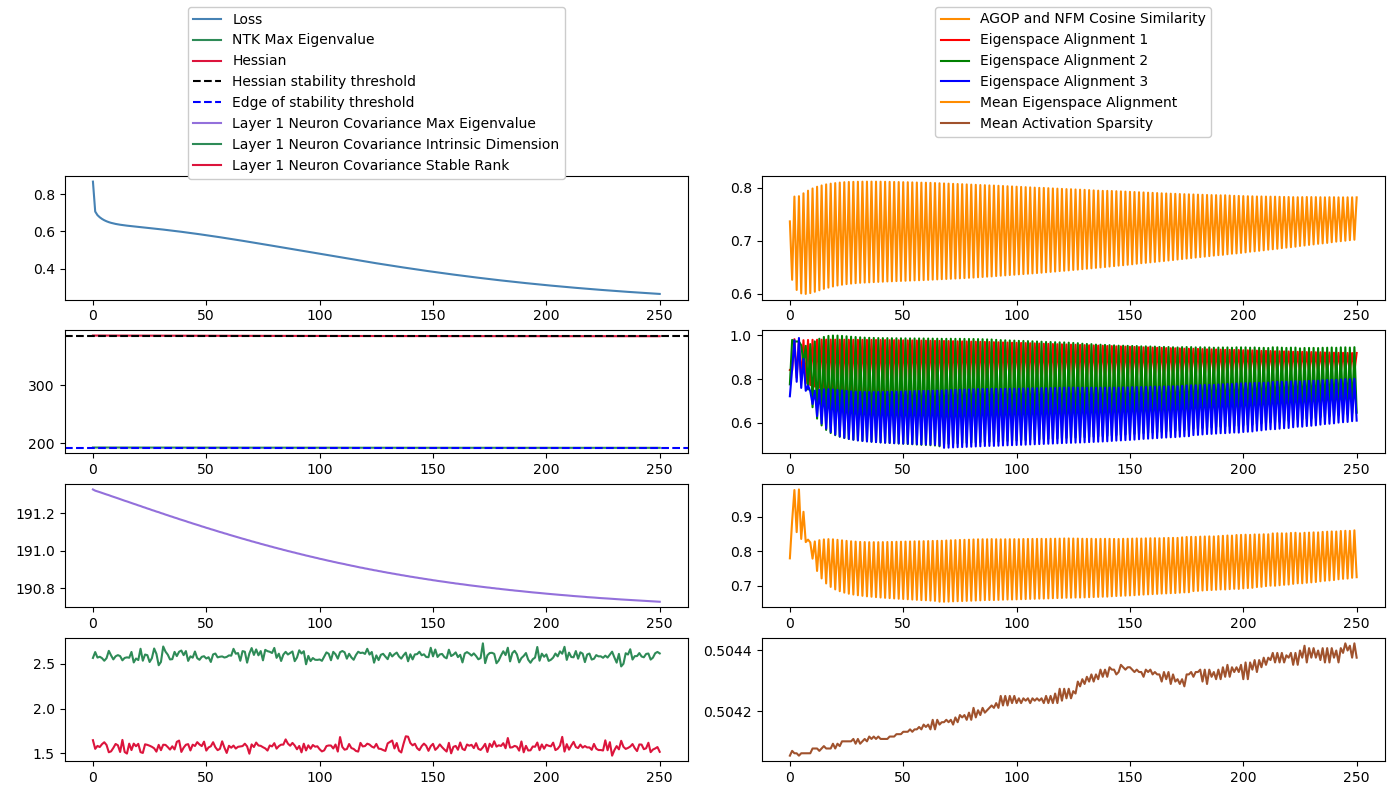

In [18]:
out = run_one(CFG, log_wandb=False)
print(f"lr={out['lr']:.5f}  eta_crit={out['eta_crit']:.5f}  "
      f"eta*lam_H={out['lr']*out['hess_lambda0']:.2f}")
print(f"loss {float(out['metrics']['loss'][0]):.4f} -> {float(out['metrics']['loss'][-1]):.4f}")
fig = plot_dynamics(out)

## 9. Sweep

`expand()` turns a `sweep:` block into one config per grid point. Each run logs to W&B under a
shared `group`, and figures are written to `outputs/<run_name>/`.

In [19]:
import pathlib

def run_sweep(config_file, save_figs=True, log_wandb=True):
    configs = expand(load_config(config_file))
    print(f"{config_file}: {len(configs)} runs")
    results = {}
    for i, cfg in enumerate(configs):
        nm = run_name(cfg)
        print(f"[{i+1}/{len(configs)}] {nm}")
        out = run_one(cfg, log_wandb=log_wandb)
        results[nm] = out
        if save_figs:
            d = pathlib.Path("../outputs") / nm
            d.mkdir(parents=True, exist_ok=True)
            plot_dynamics(out).savefig(d / "dynamics.png", dpi=120, bbox_inches="tight")
            plt.close("all")
            with open(d / "config.yaml", "w") as fh:
                yaml.safe_dump(cfg, fh)
    return results

# results = run_sweep("lr_sweep.yaml")

## 10. Cross-run comparison

The old sweep plots (cells 93, 94, 96, 98) read a global `all_losses`. Here they read the
`results` dict returned above, so nothing is hidden state. For richer exploration across runs
already in W&B, use `dashboard.ipynb`.

In [20]:
def plot_sweep_losses(results, logy=True):
    fig, ax = plt.subplots(figsize=(12, 5))
    for nm, out in sorted(results.items(), key=lambda kv: kv[1]["lr"]):
        ax.plot(out["metrics"]["loss"], label=f"lr={out['lr']:.4g}")
    ax.set(xlabel="step", ylabel="loss", yscale="log" if logy else "linear")
    ax.legend(fontsize=7, ncol=2)
    return fig